In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score


In [2]:
data = fetch_california_housing(as_frame=True)

df = pd.concat([data.data, data.target.rename("HousePrice")], axis=1)

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (20640, 8)
Target shape: (20640,)


In [4]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature scaling completed!")

Feature scaling completed!


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (16512, 8)
Testing data shape: (4128, 8)


In [6]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=42)
}

print("Models defined successfully!")

Models defined successfully!


In [8]:
results = {}

for name, model in models.items():
    
    model.fit(X_train, y_train)
    
    predictions = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    
    r2 = r2_score(y_test, predictions)
    
    results[name] = {
        "RMSE": rmse,
        "R2 Score": r2
    }

results_df = pd.DataFrame(results).T

results_df

,RMSE,R2 Score
Linear Regression,0.745581,0.575788
Ridge Regression,0.745554,0.575819
Decision Tree,0.724234,0.599732


In [9]:
best_model_name = results_df["R2 Score"].idxmax()
print("Best Model:", best_model_name)

best_rmse = results_df.loc[best_model_name, "RMSE"]
best_r2 = results_df.loc[best_model_name, "R2 Score"]

print("Best Model RMSE:", best_rmse)
print("Best Model R2 Score:", best_r2)

Best Model: Decision Tree
Best Model RMSE: 0.7242338143386247
Best Model R2 Score: 0.5997321244428706


In [10]:
best_model = models[best_model_name]
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

print("Best model retrained successfully!")

Best model retrained successfully!


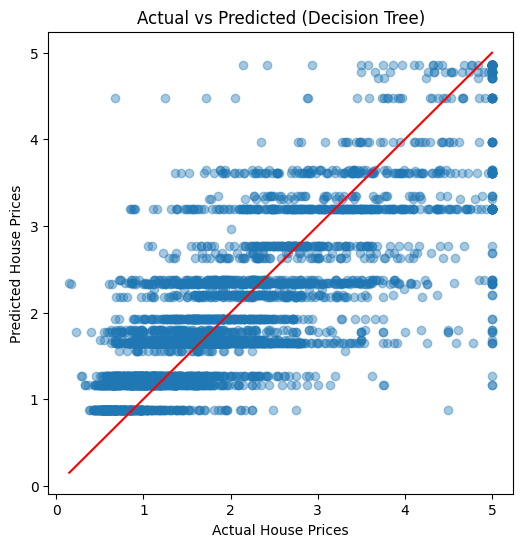

In [11]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.4)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title(f"Actual vs Predicted ({best_model_name})")

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

plt.show()

In [12]:
import joblib

joblib.dump(best_model, "best_model_task2.pkl")

print("Best model saved successfully!")

Best model saved successfully!
